In [3]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import pdf2image
import cv2
import io
import json
import base64

## Data Extraction

In [2]:
def display_image(image, prop = 1):
    cv2.imshow('Image', cv2.resize(image, (int(image.shape[1]*prop), int(image.shape[0]*prop))))
    cv2.waitKey(0)
    cv2.destroyAllWindows() 

**Image Cropping**

In [76]:
def crop_image(image, x1 = 0, y1 = 0, x2 = 0, y2 = 0):
    x2 = image.width - x2
    y2 = image.height - y2
    return np.array(image.crop((x1, y1, x2, y2)))

def get_image_from_path(path):
    images = pdf2image.convert_from_path(path)
    cropped_images = [crop_image(image, x1 = 0, y1 = 580, y2 = 100) for image in images]
    final_images = [cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY) for cropped_image in cropped_images]
    return cropped_images, final_images

In [ ]:
im1_original, im1 = get_image_from_path("src/test1.pdf")
im2_original, im2 = get_image_from_path("src/test2.pdf")

## First Page

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(im1[0], cmap='gray')
axs[1].imshow(im2[0], cmap='gray')

**Tresholds**

In [ ]:
def treshold_image(image):
    _, tresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return tresh

In [ ]:
im1_tresh = [treshold_image(image) for image in im1]
im2_tresh = [treshold_image(image) for image in im2]

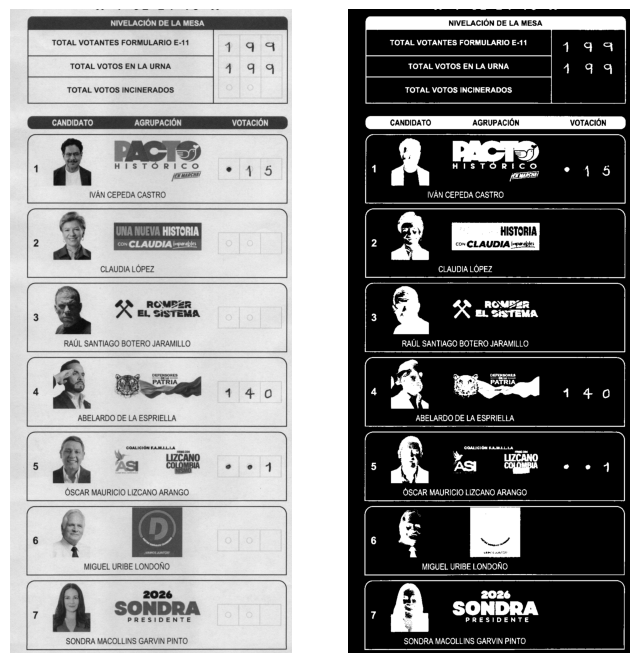

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 16))
axs[0].imshow(im2[0], cmap='gray')
axs[1].imshow(im2_tresh[0], cmap='gray')
axs[0].axis('off')
axs[1].axis('off')
plt.show()

**Contours drawing**

In [ ]:
contours, hierarchy = cv2.findContours(im1_tresh[0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
copy_image = im1_original[0].copy()
contour_im1 = cv2.drawContours(copy_image, contours[-2], -1, (255,1,0), thickness = 3)
display_image(contour_im1, prop = 0.4)

**Areas of contours**

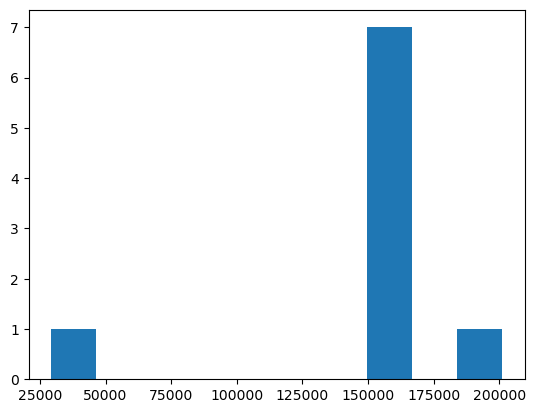

In [ ]:
areas = [cv2.contourArea(contour) for contour in contours ]
plt.hist(areas)
plt.show()

We can separate the different regions of the plot according to the contours area, perimeter and position

In [ ]:
contours = [contour for contour in contours if cv2.contourArea(contour) > 1e5]

The square with the votes is the one with the max area

In [ ]:
nivelation_contour = max(contours, key = cv2.contourArea)
votes_contours = [contour for contour in contours if contour is not nivelation_contour]

We need now to draw the bounding rectangles

Now we try to obtain the individuals votes for each one of the candidates

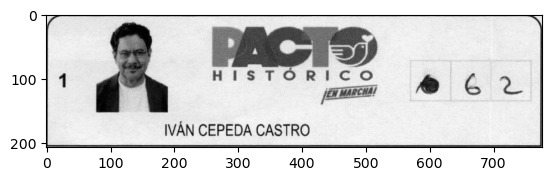

In [ ]:
votes = votes_contours[-1]
x,y,w,h = cv2.boundingRect(votes)
section = im1[0][y:y+h, x:x+w]
plt.imshow(section, cmap='gray')

To identify the candidate we need to split this section in three differents parts, the first one containing the number of candidate, the second one is not used, contains the image of the candidate and the logo of the party, finally the third sections contains the number of votes

In [ ]:
x1,x2 = int(section.shape[1]*0.08), int(section.shape[1]*0.7)
splits = []
splits.append(section[:, :x1])
splits.append(section[:, x2:])

In [ ]:
contours, hierarchy = cv2.findContours(splits[1], cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)
copy_image = splits[1].copy()
contour_im1 = cv2.drawContours(copy_image, contours, -1, (255,1,0), thickness = 5)
display_image(contour_im1, prop = 3)

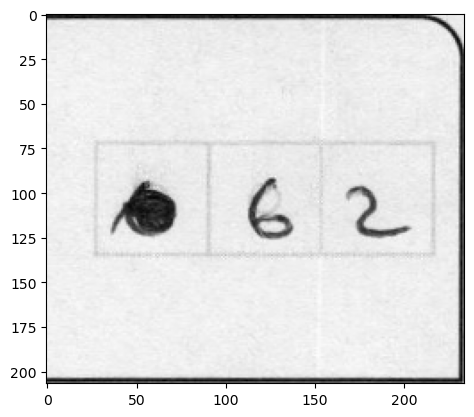

In [ ]:
plt.imshow(splits[1], cmap='gray')

## Second Page

In [ ]:
contours, hierarchy = cv2.findContours(im1_tresh[1], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
copy_image = im1_original[1].copy()
contour_im1 = cv2.drawContours(copy_image, contours, -1, (255,1,0), thickness = 3)
display_image(contour_im1, prop = 0.4)

In [ ]:
contours = [contour for contour in contours if cv2.contourArea(contour) > 1e5]

In [ ]:
total_count_contour = max(contours, key = cv2.contourArea)
votes_contours = [contour for contour in contours if contour is not total_count_contour]

In [ ]:
cv2.contourArea(contours[-1])

159595.0

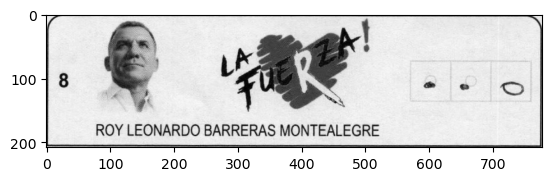

In [ ]:
votes = votes_contours[-1]
x,y,w,h = cv2.boundingRect(votes)
section = im1[1][y:y+h, x:x+w]
plt.imshow(section, cmap='gray')

## Complete Process of reduction and segmentation

In [33]:
class VoteExtractor:

    square_mask = cv2.imread('src/square_mask.png', cv2.IMREAD_GRAYSCALE)

    def __init__(self, path, filter_min=True):
        self.kernel = np.ones((3, 3), np.uint8)
        self.nivelation_lims = {"x": [0.73, 0.985], "y": [0.2, 0.95]}
        self.votes_lims = {"x": [0.1, 0.94], "y": [0.33, 0.67]}
        self.votes_split = [0.08, 0.7]
        self.total_count_lims = {"x": [0.73, 0.985], "y": [0.05, 0.95]}
        self.page_lims = {"x": [0, 1], "y": [0.23, 0.96]}
        self.original_images, self.images = self.get_image_from_path(path)
        self.filter_min = filter_min

    def display_image(self, image, prop=1):
        cv2.imshow('Image', cv2.resize(
            image, (int(image.shape[1]*prop), int(image.shape[0]*prop))))
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    def crop_image(self, image, lims):
        image = np.array(image)
        xs = lims["x"]
        ys = lims["y"]
        x1, x2 = int(image.shape[1]*xs[0]), int(image.shape[1]*xs[1])
        y1, y2 = int(image.shape[0]*ys[0]), int(image.shape[0]*ys[1])
        return image[y1:y2, x1:x2]

    def get_image_from_path(self, path):
        images = pdf2image.convert_from_path(path)
        cropped_images = [self.crop_image(
            image, self.page_lims) for image in images]
        final_images = [cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)
                        for cropped_image in cropped_images]
        return cropped_images, final_images

    def treshold_image(self, image):
        _, tresh = cv2.threshold(
            image, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return tresh

    def get_contours(self, image, filter_min=True, min_area=1e5):
        contours, _ = cv2.findContours(
            image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if filter_min:
            contours = [contour for contour in contours if cv2.contourArea(
                contour) > min_area]
        return contours

    def get_centroid(self, contour):
        M = cv2.moments(contour)
        if M['m00'] == 0:
            return (0, 0)
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
        return (cx, cy)

    def split_first_page(self, image, contours):
        nivelation_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(nivelation_contour)
        nivelation = image[y:y+h, x:x+w]
        nivelation = self.crop_image(nivelation, self.nivelation_lims)
        votes_contours = [
            contour for contour in contours if contour is not nivelation_contour]
        votes_contours = sorted(votes_contours,
                                key=lambda contour: self.get_centroid(contour)[
                                    0],
                                reverse=True)
        sections = []
        for votes in votes_contours:
            x, y, w, h = cv2.boundingRect(votes)
            section = image[y:y+h, x:x+w]
            sections.append(section)
        return nivelation, sections

    def split_second_page(self, image, contours):
        total_count_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(total_count_contour)
        total_count = image[y:y+h, x:x+w]
        total_count = self.crop_image(total_count, self.total_count_lims)

        votes_contours = [
            contour for contour in contours if contour is not total_count_contour]
        votes_contours = sorted(votes_contours,
                                key=lambda contour: self.get_centroid(contour)[
                                    0],
                                reverse=True)
        sections = []
        for votes in votes_contours:
            x, y, w, h = cv2.boundingRect(votes)
            section = image[y:y+h, x:x+w]
            sections.append(section)
        return total_count, sections

    def get_candidates_votes(self, image):
        s1, s2 = self.votes_split
        x2 = int(image.shape[1]*s2)
        votes = self.crop_image(image[:, x2:], self.votes_lims)
        return votes

    def get_sections(self):
        images = self.images
        contours_page1 = self.get_contours(
            self.treshold_image(images[0]), filter_min=self.filter_min)
        contours_page2 = self.get_contours(
            self.treshold_image(images[1]), filter_min=self.filter_min)
        voters = []
        nivelation, sections = self.split_first_page(images[0], contours_page1)
        voters.extend(sections)
        total_count, sections = self.split_second_page(
            images[1], contours_page2)
        voters.extend(sections)
        candidates_votes = [self.get_candidates_votes(image) for image in voters]
        return nivelation, total_count, candidates_votes

    def clean_cell(self, cell):
        box_mask = self.square_mask
        box_mask = cv2.resize(box_mask, (cell.shape[1], cell.shape[0]), interpolation=cv2.INTER_NEAREST)
        ink_mask = cv2.threshold(cell, 170, 255, cv2.THRESH_BINARY_INV)[1]
        bg_color = cell.mean()
        erase_mask = cv2.bitwise_and(box_mask, cv2.bitwise_not(ink_mask))
        clean_cell = cell.copy()
        clean_cell[erase_mask == 255] = bg_color
        return clean_cell
    
    def split_cells(self, image, splits=(1, 1), clean = False):
        h, w = image.shape
        dx = w//splits[1]
        dy = h//splits[0]
        cells = []
        for i in range(splits[0]):
            y_splits = []
            for j in range(splits[1]):
                if clean and j != 2:
                    cell = self.clean_cell(image[i*dy:(i+1)*dy, j*dx:(j+1)*dx])
                else:
                    cell = image[i*dy:(i+1)*dy, j*dx:(j+1)*dx]
                y_splits.append(cell)
            cells.append(y_splits)
        return np.array(cells)

    def get_act_votes(self, clean=False):
        nivelation, total_count, candidates_votes = self.get_sections()
        n_splits = self.split_cells(nivelation, splits = (3,3), clean = clean)
        t_splits = self.split_cells(total_count, splits = (4,3), clean = clean)
        candidates_votes = [self.split_cells(image, splits = (1,3), clean = clean)[0] for image in candidates_votes]
        return n_splits, t_splits, candidates_votes
    
    def convert_image_to_json(self, image):
        pil = Image.fromarray(image, mode='L')
        with io.BytesIO() as output:
            pil.save(output, format="PNG")
            png_data = output.getvalue()
        return base64.b64encode(png_data).decode('utf-8')
       
    def get_votes_as_json(self, clean=False):
        n_splits, t_splits, candidates_votes = self.get_act_votes(clean=clean)
        data = {}
        total_E11_data = []
        total_ballot_box_data = []
        total_burned_data = []
        for i in range(t_splits.shape[1]):
            total_E11_data.append(self.convert_image_to_json(t_splits[0, i]))
            total_ballot_box_data.append(self.convert_image_to_json(t_splits[1, i]))
            total_burned_data.append(self.convert_image_to_json(t_splits[2, i]))
        
        data["nivelation"] ={
            "total_E11": total_E11_data,
            "total_ballot_box": total_ballot_box_data,
            "total_burned": total_burned_data
            }
        
        blank_data = []
        null_data = []
        not_marked_data = []
        for i in range(n_splits.shape[1]):
            blank_data.append(self.convert_image_to_json(n_splits[0, i]))
            null_data.append(self.convert_image_to_json(n_splits[1, i]))
            not_marked_data.append(self.convert_image_to_json(n_splits[2, i]))

        data["total_votes"] = {
            "blank": blank_data,
            "null": null_data,
            "not_marked": not_marked_data
        }

        data["candidates_votes"] = {}
        for i, candidate in enumerate(candidates_votes):
            candidate_data = []
            for j in range(candidate.shape[0]):
                cell = self.convert_image_to_json(candidate[j])
                candidate_data.append(cell)
            data["candidates_votes"][f"candidate_{i+1}"] = candidate_data

        return data
    
    def save_votes_as_json(self, filename, clean=False):
        data = self.get_votes_as_json(clean=clean)
        with open(filename, 'w') as f:
            json.dump(data, f)

In [34]:
EX = VoteExtractor("src/test1.pdf")
n,t,candidates = EX.get_act_votes()

In [36]:
EX.save_votes_as_json("src/votes.json", clean=False)